# Лабораторная работа №2

В данной лабораторной работе мы проведем изучение способов предварительной обработки данных для дальнейшего формирования моделей.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")

### Задание:

Выбрать набор данных (датасет), содержащий категориальные признаки и пропуски в данных. Для выполнения следующих пунктов можно использовать несколько различных наборов данных (один для обработки пропусков, другой для категориальных признаков и т.д.)
Для выбранного датасета (датасетов) на основе материалов лекции решить следующие задачи:
* обработку пропусков в данных;
* кодирование категориальных признаков;
* масштабирование данных.


## Загрузка и анализ данных

Наш датасет: https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who

In [6]:
data = pd.read_csv('data/lifeexp.xls', sep=",")

In [7]:
# Форма данных
data.shape

(2938, 22)

In [8]:
# Типы колонок
data.dtypes

Country                             object
Year                                 int64
Status                              object
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
 BMI                               float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
 HIV/AIDS                          float64
GDP                                float64
Population                         float64
 thinness  1-19 years              float64
 thinness 5-9 years                float64
Income composition of resources    float64
Schooling                          float64
dtype: object

In [9]:
# Проверим датасет на наличие пропусков
data.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64

In [10]:
# Первые 5 строк датасета
data.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


## Обработка пропусков

Сначала проведем работу с датасетом с пропусками в данных.

Пропуски в данных - препятствие в решении задач машинного обучения, так как они могут нарушить работу множества алгоритмов. Разберем пути преодоления проблемы.

### Пропуск данных

Один из простейших подходов. Мы можем исключить из рассмотрения строки датасета, где имеются пропуски в любых колонках.

Альтернатива - исключить из модели признаки (столбцы), где имеются пропуски.

In [13]:
# Удаление строк, содержащих пустые значения
data_new_1 = data.dropna(axis=0, how='any')
# Сравним исходные и преобразованные данные
(data.shape, data_new_1.shape)

((2938, 22), (1649, 22))

In [15]:
# Удаление колонок, содержащих пустые значения
data_new_2 = data.dropna(axis=1, how='any')
# Сравним исходные и преобразованные данные
(data.shape, data_new_2.shape)

((2938, 22), (2938, 8))

In [19]:
# Первые пять строк исходного датасета
data.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [20]:
# Первые пять строк датасета при исключении строк с пропусками
data_new_1.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [21]:
# Первые пять строк датасета при исключении колонок с пропусками
data_new_2.head()

,Country,Year,Status,infant deaths,percentage expenditure,Measles,under-five deaths,HIV/AIDS
0,Afghanistan,2015,Developing,62,71.279624,1154,83,0.1
1,Afghanistan,2014,Developing,64,73.523582,492,86,0.1
2,Afghanistan,2013,Developing,66,73.219243,430,89,0.1
3,Afghanistan,2012,Developing,69,78.184215,2787,93,0.1
4,Afghanistan,2011,Developing,71,7.097109,3013,97,0.1


### Заполнение нулями

По простоте аналогичен пропуску данных, но позволяет не исключать строки с пропущенными данными. Всё, что для этого делается при примещении этой методики - пропущенные значения заменяются нулевыми. 

In [23]:
# Заполнение всех пропущенных значений нулями
data_new_3 = data.fillna(0)
# 20 случайных строк
data_new_3.sample(20)

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
2210,Samoa,2005,Developing,71.6,16.0,0,3.63,287.467130,41.0,0,...,55.0,4.47,49.0,0.1,2571.262348,179929.0,0.2,0.2,0.671,12.6
2116,Republic of Moldova,2002,Developing,67.5,225.0,1,6.71,0.000000,99.0,4929,...,98.0,8.31,97.0,0.1,0.000000,0.0,3.4,3.6,0.000,0.0
1384,Kiribati,2009,Developing,65.2,28.0,0,0.54,162.290371,86.0,0,...,84.0,12.24,86.0,0.1,1297.285141,1568.0,0.1,0.1,0.576,11.9
804,Egypt,2013,Developing,79.0,159.0,54,0.21,0.000000,97.0,405,...,97.0,5.46,97.0,0.1,0.000000,0.0,2.9,2.8,0.681,12.8
2332,Slovakia,2012,Developed,75.8,118.0,0,10.12,0.000000,99.0,0,...,99.0,8.15,99.0,0.1,0.000000,0.0,1.2,1.3,0.835,15.0
1688,Mexico,2010,Developing,75.6,127.0,35,5.21,1033.039737,93.0,0,...,95.0,6.39,95.0,0.1,8959.581416,117318941.0,1.6,1.6,0.739,12.5
2443,Sri Lanka,2013,Developing,74.6,142.0,3,2.56,41.620536,99.0,2107,...,99.0,3.68,99.0,0.1,361.289374,2585.0,15.2,15.1,0.757,13.8
2643,Tonga,2005,Developing,72.3,15.0,0,1.57,689.944022,89.0,0,...,9.0,6.52,89.0,0.1,2594.749990,1141.0,0.1,0.1,0.694,14.6
104,Armenia,2007,Developing,73.5,132.0,1,3.99,44.572200,85.0,1,...,9.0,4.31,88.0,0.1,3138.887300,293356.0,2.0,2.1,0.707,11.7
2140,Russian Federation,2010,Developing,68.4,256.0,15,11.05,162.808805,97.0,129,...,98.0,6.83,97.0,0.2,1674.987710,142849449.0,2.3,2.5,0.773,13.7


### Импьютация

Это более сложный метод, предполагающий синтез пропущенных данных на основе имеющихся. Существует целое множество алгоритмов импьютации. В этом примере мы будем пользоваться возможностями импьютации библиотеки scikit-learn.

#### Импьютация числовых признаков

In [25]:
# Выберем числовые колонки с пропущенными значениями
# Цикл по колонкам датасета
total_count = data.shape[0]
num_cols = []
for col in data.columns:
    # Количество пустых значений 
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='float64' or dt=='int64'):
        num_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

Колонка Life expectancy . Тип данных float64. Количество пустых значений 10, 0.34%.
Колонка Adult Mortality. Тип данных float64. Количество пустых значений 10, 0.34%.
Колонка Alcohol. Тип данных float64. Количество пустых значений 194, 6.6%.
Колонка Hepatitis B. Тип данных float64. Количество пустых значений 553, 18.82%.
Колонка  BMI . Тип данных float64. Количество пустых значений 34, 1.16%.
Колонка Polio. Тип данных float64. Количество пустых значений 19, 0.65%.
Колонка Total expenditure. Тип данных float64. Количество пустых значений 226, 7.69%.
Колонка Diphtheria . Тип данных float64. Количество пустых значений 19, 0.65%.
Колонка GDP. Тип данных float64. Количество пустых значений 448, 15.25%.
Колонка Population. Тип данных float64. Количество пустых значений 652, 22.19%.
Колонка  thinness  1-19 years. Тип данных float64. Количество пустых значений 34, 1.16%.
Колонка  thinness 5-9 years. Тип данных float64. Количество пустых значений 34, 1.16%.
Колонка Income composition of resourc

In [27]:
# Фильтр по колонкам с пропущенными значениями
data_num = data[num_cols]
data_num

,Life expectancy,Adult Mortality,Alcohol,Hepatitis B,BMI,Polio,Total expenditure,Diphtheria,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,65.0,263.0,0.01,65.0,19.1,6.0,8.16,65.0,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,59.9,271.0,0.01,62.0,18.6,58.0,8.18,62.0,612.696514,327582.0,17.5,17.5,0.476,10.0
2,59.9,268.0,0.01,64.0,18.1,62.0,8.13,64.0,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,59.5,272.0,0.01,67.0,17.6,67.0,8.52,67.0,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,59.2,275.0,0.01,68.0,17.2,68.0,7.87,68.0,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,44.3,723.0,4.36,68.0,27.1,67.0,7.13,65.0,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,44.5,715.0,4.06,7.0,26.7,7.0,6.52,68.0,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,44.8,73.0,4.43,73.0,26.3,73.0,6.53,71.0,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,45.3,686.0,1.72,76.0,25.9,76.0,6.16,75.0,548.587312,12366165.0,1.6,1.7,0.427,9.8


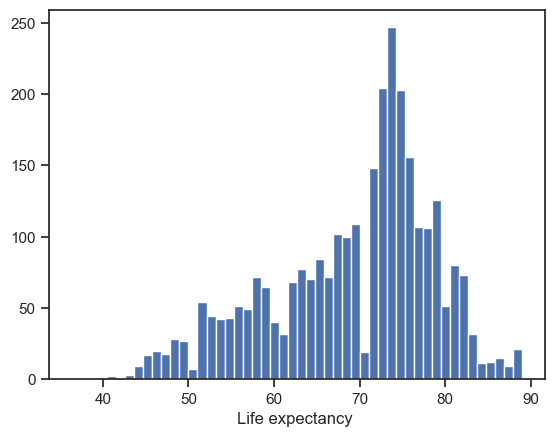

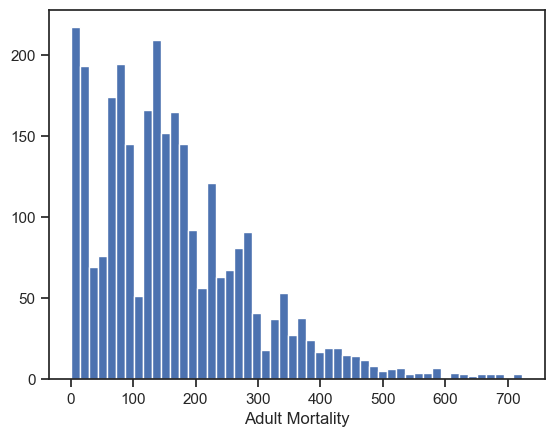

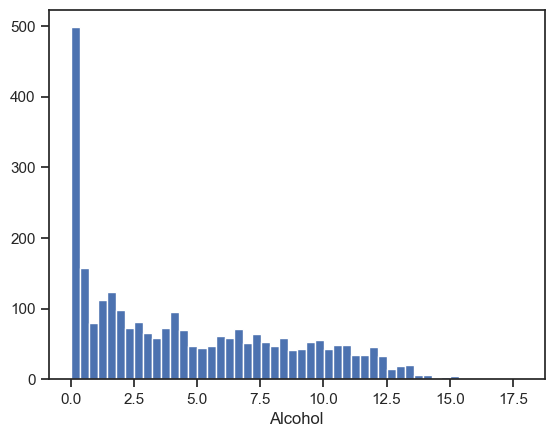

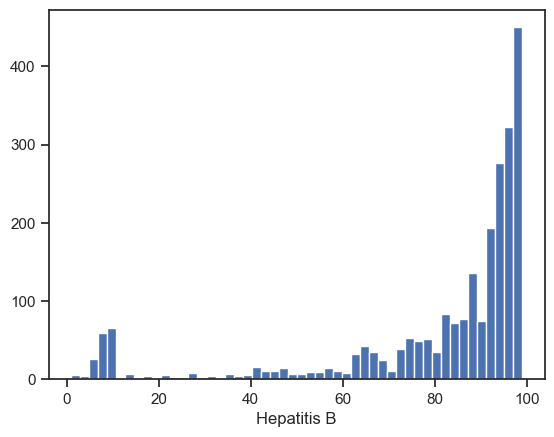

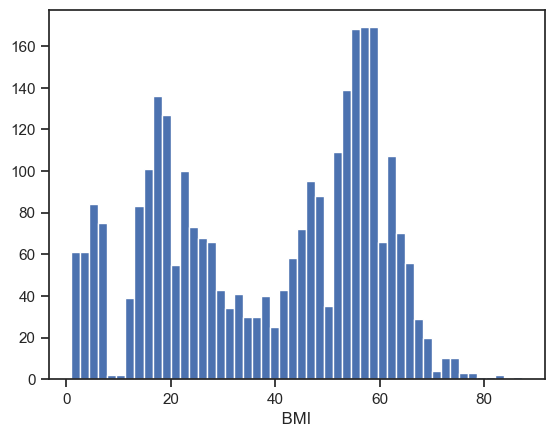

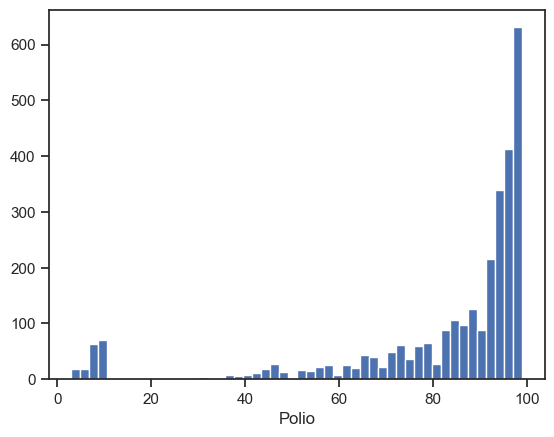

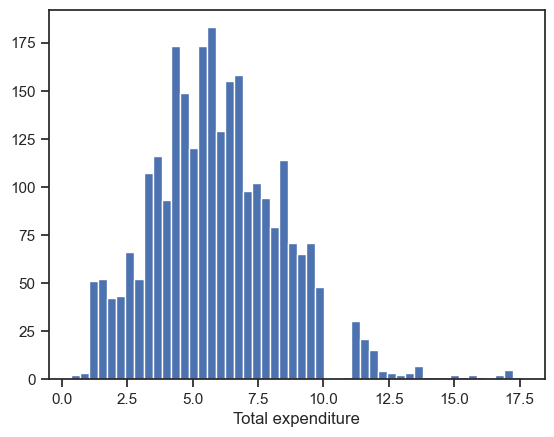

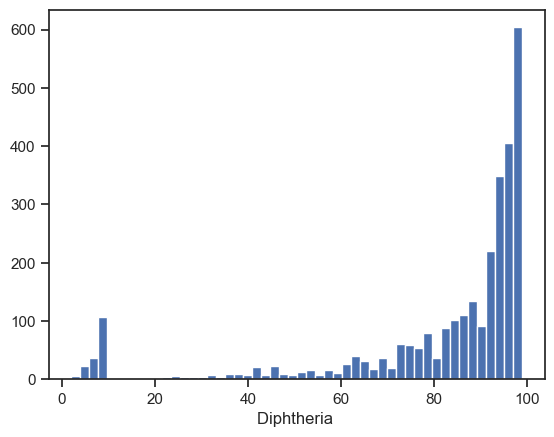

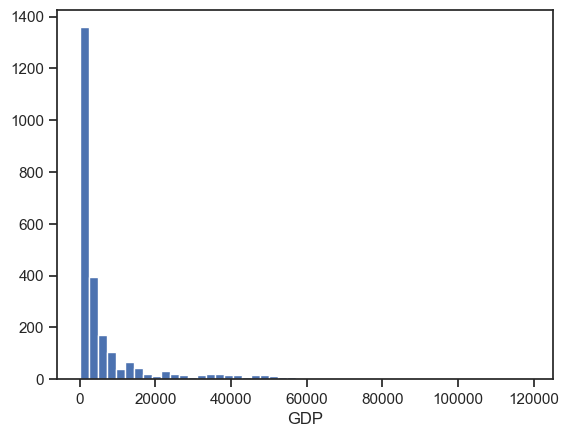

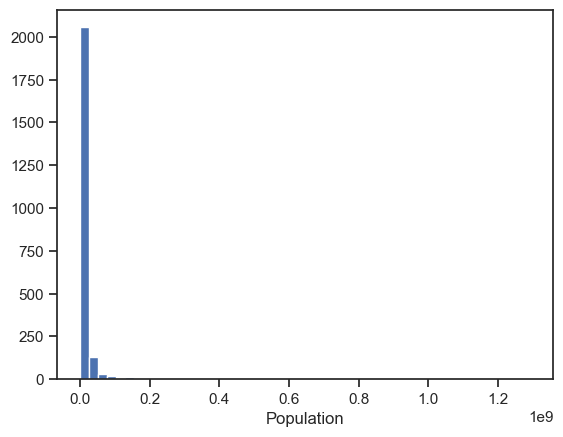

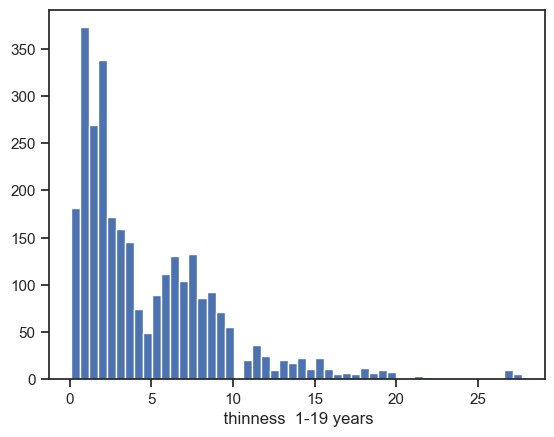

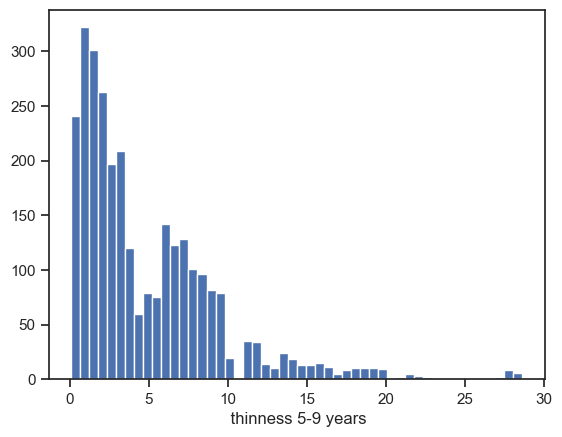

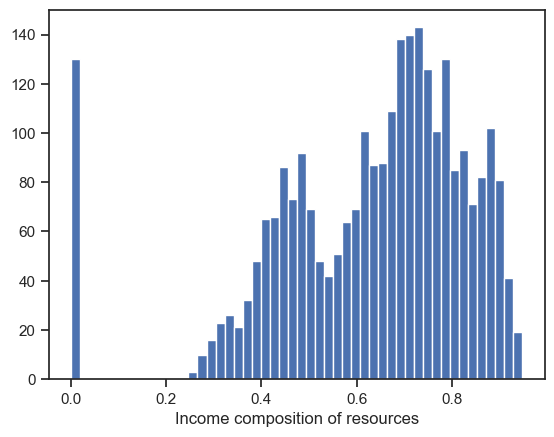

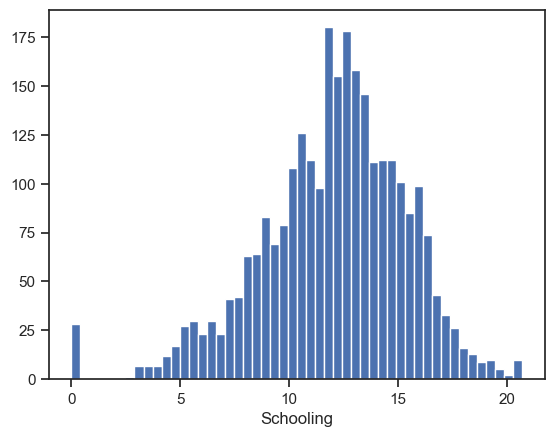

In [31]:
# Гистограмма по признакам
for col in data_num:
    plt.hist(data[col], 50)
    plt.xlabel(col)
    plt.show()

In [37]:
from sklearn.impute import SimpleImputer
from sklearn.impute import MissingIndicator

In [41]:
# Функция, которая позволяет задавать колонку и вид импьютации
strategies=['mean', 'median', 'most_frequent']
def test_num_impute_col(dataset, column, strategy_param):
    temp_data = dataset[[column]]
    
    indicator = MissingIndicator()
    mask_missing_values_only = indicator.fit_transform(temp_data)
    
    imp_num = SimpleImputer(strategy=strategy_param)
    data_num_imp = imp_num.fit_transform(temp_data)
    
    filled_data = data_num_imp[mask_missing_values_only]
    
    return column, strategy_param, filled_data.size, filled_data[0], filled_data[filled_data.size-1]

In [42]:
# Импьютируем данные в одну из колонок разными способами
# Сначала в численном виде опишем колонку
data[[' BMI ']].describe()

,BMI
count,2904.000000
mean,38.321247
std,20.044034
min,1.000000
25%,19.300000
50%,43.500000
75%,56.200000
max,87.300000


In [44]:
# Синтезированные данные основываются на среднем
test_num_impute_col(data, ' BMI ', strategies[0])

(' BMI ',
 'mean',
 34,
 np.float64(38.321246556473824),
 np.float64(38.321246556473824))

In [45]:
# Синтезированные данные основываются на медиане
test_num_impute_col(data, ' BMI ', strategies[1])

(' BMI ', 'median', 34, np.float64(43.5), np.float64(43.5))

In [46]:
# Синтезированные данные основываются на наиболее часто встречающейся величине
test_num_impute_col(data, ' BMI ', strategies[2])

(' BMI ', 'most_frequent', 34, np.float64(58.5), np.float64(58.5))

## Кодирование категориальных признаков

Алгоритмы машинного обучения обычно работают с числами. Это значит, что мы лишаемся многих инструментов анализа данных и машинного обучения, сохраняя в датасете категориальные признаки. Это можно исправить, выполнив кодирование категориальных признаков.

### Кодирование целочисленными значения

Простой принцип - сопоставить уникальным значениям множества категориального признака целые числа.

В scikit-learn для такого кодирования используются два класса:

* LabelEncoder - который ориентирован на применение к одному признаку. Этот класс прежде всего предназначен для кодирования целевого признака, но может быть также использован для последовательного кодирования отдельных нецелевых признаков.
  * OrdinalEncoder - который ориентирован на применение к матрице объект-признак, то есть для кодирования матрицы нецелевых признаков.

In [54]:
# Сменим датасет

data_2 = pd.read_csv('data/accessories.csv', sep=",")

# Форма данных
data_2.shape

(222, 22)

In [55]:
# Типы колонок
data_2.dtypes

Name                      object
Variation                 object
DIY                       object
Buy                       object
Sell                       int64
Color 1                   object
Color 2                   object
Size                      object
Miles Price              float64
Source                    object
Source Notes              object
Seasonal Availability     object
Mannequin Piece           object
Version                   object
Style                     object
Label Themes              object
Type                      object
Villager Equippable       object
Catalog                   object
Filename                  object
Internal ID                int64
Unique Entry ID           object
dtype: object

In [57]:
data_2.head()

,Name,Variation,DIY,Buy,Sell,Color 1,Color 2,Size,Miles Price,Source,...,Mannequin Piece,Version,Style,Label Themes,Type,Villager Equippable,Catalog,Filename,Internal ID,Unique Entry ID
0,3D glasses,White,No,490,122,White,Colorful,1x1,NaN,Able Sisters,...,No,1.0.0,Active,party,AccessoryEye,Yes,For sale,AccessoryGlassThreed0,4463,FNxEraBTeWRiCvtFu
1,3D glasses,Black,No,490,122,Black,Colorful,1x1,NaN,Able Sisters,...,No,1.0.0,Active,party,AccessoryEye,Yes,For sale,AccessoryGlassThreed1,11020,mM9SXPCcGPfPJAmtm
2,bandage,Beige,No,140,35,Beige,White,1x1,NaN,Able Sisters,...,Yes,1.0.0,Active,outdoorsy; comfy; sporty,AccessoryMouth,No,For sale,AccessoryMouthBandageSkin,4677,2qFT5iPkk8bREvpkj
3,beak,Yellow,No,490,122,Yellow,Yellow,1x1,NaN,Able Sisters,...,Yes,1.0.0,Cute,fairy tale; party; theatrical,AccessoryMouthInvisibleNose,No,For sale,AccessoryMouthBeakYellow,3549,T5CpsJi4xBSachNL5
4,birthday shades,Yellow,No,NFS,620,Yellow,Red,1x1,NaN,Birthday,...,No,1.0.0,Gorgeous,party,AccessoryEye,Yes,Not for sale,AccessoryGlassBirthday0,4510,S6CiB9ZvzBTMhEnDz


#### LabelEncoder

In [58]:
from sklearn.preprocessing import LabelEncoder

In [61]:
# Для примера рассмотрим признак Variation

data_2['Variation'].unique()

array(['White', 'Black', 'Beige', 'Yellow', 'Pink', 'Red', 'Blue',
       'Purple', 'Green', 'Brown', 'Gray', 'Orange', 'Navy blue',
       'Silver', 'Gold', 'Pasta', 'Avocado', 'Twilight', 'Midnight',
       'Passion', 'Ocean', 'Sunset', 'Love', 'Light blue', 'Magenta',
       'Mustard', 'Baby purple', 'Baby mint', 'Baby yellow', 'Baby green',
       'Baby pink', 'Baby gray', 'Baby blue', 'Baby orange', 'Ochre',
       'Light brown', 'Dark brown', 'Lime', 'Berry red'], dtype=object)

In [62]:
le = LabelEncoder()
data_2_enc_le = le.fit_transform(data_2['Variation'])

In [63]:
# Наименования категорий в соответствии с порядковыми номерами

# Свойство называется classes, потому что предполагается что мы решаем 
# задачу классификации и каждое значение категории соответствует 
# какому-либо классу целевого признака

le.classes_

array(['Avocado', 'Baby blue', 'Baby gray', 'Baby green', 'Baby mint',
       'Baby orange', 'Baby pink', 'Baby purple', 'Baby yellow', 'Beige',
       'Berry red', 'Black', 'Blue', 'Brown', 'Dark brown', 'Gold',
       'Gray', 'Green', 'Light blue', 'Light brown', 'Lime', 'Love',
       'Magenta', 'Midnight', 'Mustard', 'Navy blue', 'Ocean', 'Ochre',
       'Orange', 'Passion', 'Pasta', 'Pink', 'Purple', 'Red', 'Silver',
       'Sunset', 'Twilight', 'White', 'Yellow'], dtype=object)

In [65]:
# Просмотрим результат кодирования
data_2_enc_le

array([37, 11,  9, 38, 38, 31, 33, 12, 33, 32, 17, 12, 38, 31, 11, 11, 13,
       17, 16, 31, 12, 38, 17, 37, 31, 38, 37, 12, 33, 13, 32, 28, 12, 37,
       13, 25, 17, 11, 33, 11, 34, 32, 17, 38, 12, 38, 37, 37,  9, 11, 15,
       32, 34, 12, 17, 12, 31, 37, 12, 31, 16, 17, 28, 33, 11, 37, 33, 33,
       28, 12, 32, 17, 30, 13, 31, 12, 11,  0, 11, 11, 11, 12, 31, 17, 32,
       33, 11, 31, 38, 12, 32, 17, 37, 11, 33, 17, 12, 36, 23, 29, 26, 35,
       21, 33, 12, 17, 31, 38, 15, 17, 32, 11, 12, 33, 17, 15, 11, 15, 34,
       11, 17, 18, 16, 17, 32, 15, 11, 17, 28, 12, 32, 22, 24, 11,  7,  4,
        8,  3,  6,  2,  1,  5, 31, 11, 15, 33, 17, 12, 11, 11, 37, 11, 16,
       38, 17, 33, 32, 12, 16, 33, 27, 32, 11, 15, 16, 13, 32, 11, 17, 12,
       38, 31, 33, 37, 32, 13, 19, 14, 17, 11, 11, 37, 38, 32, 31, 17, 28,
       11, 37, 31, 20, 18, 13, 11, 16, 12, 11, 33, 38, 31, 12, 32, 17, 17,
       32, 37, 11, 15, 11, 10, 13,  9, 11, 33, 28, 12, 32, 17, 37, 11, 13,
       14])

In [66]:
np.unique(data_2_enc_le)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38])

#### OrdinalEncoder

In [68]:
from sklearn.preprocessing import OrdinalEncoder

In [69]:
# OrdinalEncoder работает для кодирования матрицы нецелевых признаков

data_2_oe = data_2[['Variation', 'Size', 'Buy']]
data_2_oe.head()

,Variation,Size,Buy
0,White,1x1,490
1,Black,1x1,490
2,Beige,1x1,140
3,Yellow,1x1,490
4,Yellow,1x1,NFS


In [70]:
imp4 = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='NA')
data_2_oe_filled = imp4.fit_transform(data_2_oe)
data_2_oe_filled

array([['White', '1x1', '490'],
       ['Black', '1x1', '490'],
       ['Beige', '1x1', '140'],
       ['Yellow', '1x1', '490'],
       ['Yellow', '1x1', 'NFS'],
       ['Pink', '1x1', 'NFS'],
       ['Red', '1x1', 'NFS'],
       ['Blue', '1x1', 'NFS'],
       ['Red', '1x1', '1100'],
       ['Purple', '1x1', '1100'],
       ['Green', '1x1', '1100'],
       ['Blue', '1x1', '1100'],
       ['Yellow', '1x1', '1100'],
       ['Pink', '1x1', '1100'],
       ['Black', '1x1', '1100'],
       ['Black', '1x1', '1040'],
       ['Brown', '1x1', '1040'],
       ['Green', '1x1', '1040'],
       ['Gray', '1x1', '1040'],
       ['Pink', '1x1', '140'],
       ['Blue', '1x1', '140'],
       ['Yellow', '1x1', '140'],
       ['Green', '1x1', '140'],
       ['White', '1x1', '140'],
       ['Pink', '1x1', '560'],
       ['Yellow', '1x1', '560'],
       ['White', '1x1', '560'],
       ['Blue', '1x1', '1040'],
       ['Red', '1x1', '1040'],
       ['Brown', '1x1', '1040'],
       ['Purple', '1x1', 'NFS'],
  

In [71]:
oe = OrdinalEncoder()
cat_2_enc_oe = oe.fit_transform(data_2_oe_filled)
cat_2_enc_oe

array([[37.,  0.,  9.],
       [11.,  0.,  9.],
       [ 9.,  0.,  5.],
       [38.,  0.,  9.],
       [38.,  0., 17.],
       [31.,  0., 17.],
       [33.,  0., 17.],
       [12.,  0., 17.],
       [33.,  0.,  1.],
       [32.,  0.,  1.],
       [17.,  0.,  1.],
       [12.,  0.,  1.],
       [38.,  0.,  1.],
       [31.,  0.,  1.],
       [11.,  0.,  1.],
       [11.,  0.,  0.],
       [13.,  0.,  0.],
       [17.,  0.,  0.],
       [16.,  0.,  0.],
       [31.,  0.,  5.],
       [12.,  0.,  5.],
       [38.,  0.,  5.],
       [17.,  0.,  5.],
       [37.,  0.,  5.],
       [31.,  0., 10.],
       [38.,  0., 10.],
       [37.,  0., 10.],
       [12.,  0.,  0.],
       [33.,  0.,  0.],
       [13.,  0.,  0.],
       [32.,  0., 17.],
       [28.,  0., 17.],
       [12.,  0., 17.],
       [37.,  0., 10.],
       [13.,  0., 10.],
       [25.,  0., 10.],
       [17.,  0.,  9.],
       [11.,  0., 12.],
       [33.,  0.,  3.],
       [11.,  0.,  3.],
       [34.,  0.,  3.],
       [32.,  0.

In [73]:
# Уникальные значения 1 признака
np.unique(cat_2_enc_oe[:, 0])

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
       26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.])

In [74]:
# Уникальные значения 2 признака
np.unique(cat_2_enc_oe[:, 1])

array([0.])

In [75]:
# Уникальные значения 3 признака
np.unique(cat_2_enc_oe[:, 2])

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17.])

In [76]:
# Наименования категорий в соответствии с порядковыми номерами
oe.categories_

[array(['Avocado', 'Baby blue', 'Baby gray', 'Baby green', 'Baby mint',
        'Baby orange', 'Baby pink', 'Baby purple', 'Baby yellow', 'Beige',
        'Berry red', 'Black', 'Blue', 'Brown', 'Dark brown', 'Gold',
        'Gray', 'Green', 'Light blue', 'Light brown', 'Lime', 'Love',
        'Magenta', 'Midnight', 'Mustard', 'Navy blue', 'Ocean', 'Ochre',
        'Orange', 'Passion', 'Pasta', 'Pink', 'Purple', 'Red', 'Silver',
        'Sunset', 'Twilight', 'White', 'Yellow'], dtype=object),
 array(['1x1'], dtype=object),
 array(['1040', '1100', '1120', '1300', '1320', '140', '1560', '1760',
        '2000', '490', '560', '630', '700', '770', '880', '910', '980',
        'NFS'], dtype=object)]

In [77]:
# Обратное преобразование
oe.inverse_transform(cat_2_enc_oe)

array([['White', '1x1', '490'],
       ['Black', '1x1', '490'],
       ['Beige', '1x1', '140'],
       ['Yellow', '1x1', '490'],
       ['Yellow', '1x1', 'NFS'],
       ['Pink', '1x1', 'NFS'],
       ['Red', '1x1', 'NFS'],
       ['Blue', '1x1', 'NFS'],
       ['Red', '1x1', '1100'],
       ['Purple', '1x1', '1100'],
       ['Green', '1x1', '1100'],
       ['Blue', '1x1', '1100'],
       ['Yellow', '1x1', '1100'],
       ['Pink', '1x1', '1100'],
       ['Black', '1x1', '1100'],
       ['Black', '1x1', '1040'],
       ['Brown', '1x1', '1040'],
       ['Green', '1x1', '1040'],
       ['Gray', '1x1', '1040'],
       ['Pink', '1x1', '140'],
       ['Blue', '1x1', '140'],
       ['Yellow', '1x1', '140'],
       ['Green', '1x1', '140'],
       ['White', '1x1', '140'],
       ['Pink', '1x1', '560'],
       ['Yellow', '1x1', '560'],
       ['White', '1x1', '560'],
       ['Blue', '1x1', '1040'],
       ['Red', '1x1', '1040'],
       ['Brown', '1x1', '1040'],
       ['Purple', '1x1', 'NFS'],
  

## Масштабирование данных

Нередко данные лежат в пределах разных порядков значений. Это может помешать алгоритмам их обработки, поэтому предварительно данные следует отмасштабировать -- изменить диапазон их значений.

Рассмотрим два способа масштабирования данных: 
- MinMax масштабирование:
  $$ x_{новый} = \frac{x_{старый} - min(X)}{max(X)-min(X)} $$
    В этом случае значения лежат в диапазоне от 0 до 1.
- Масштабирование данных на основе Z-оценки:
  $$ x_{новый} = \frac{x_{старый} - AVG(X) }{\sigma(X)} $$
    В этом случае большинство значений попадает в диапазон от -3 до 3.
 где $X$ - матрица объект-признак, $AVG(X)$ - среднее значение, $\sigma$ - среднеквадратичное отклонение.

In [78]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer

Используем датасет о качестве питьевой воды: https://www.kaggle.com/datasets/adityakadiwal/water-potability

In [79]:
data_3 = pd.read_csv('data/water_potability.csv', sep=",")

# Форма данных
data_3.shape

(3276, 10)

In [80]:
# Типы колонок
data_3.dtypes

ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object

In [81]:
data_3.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


### MinMax масштабирование

In [82]:
sc1 = MinMaxScaler()
sc1_data = sc1.fit_transform(data_3[['Sulfate']])

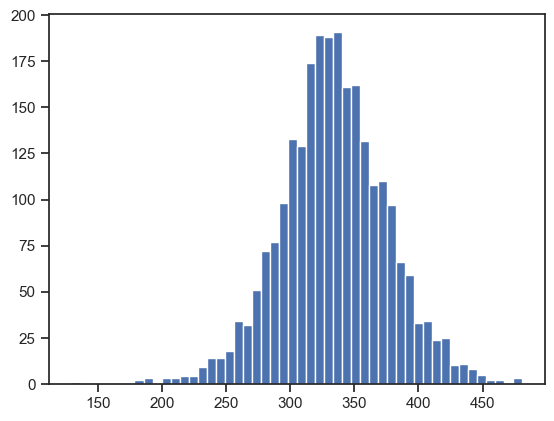

In [84]:
plt.hist(data_3['Sulfate'], 50)
plt.show()

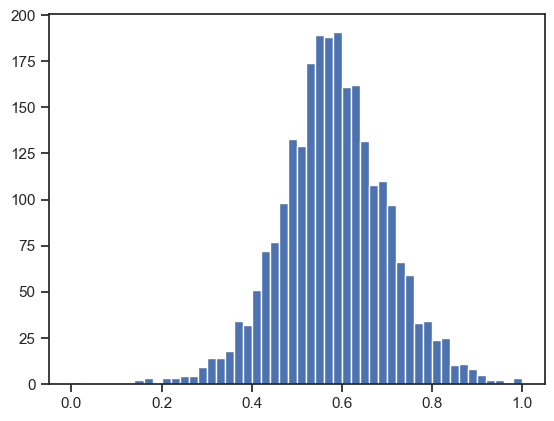

In [85]:
plt.hist(sc1_data, 50)
plt.show()

### Масштабирование данных на основе Z-оценки - StandardScaler

In [86]:
sc2 = StandardScaler()
sc2_data = sc2.fit_transform(data_3[['Sulfate']])

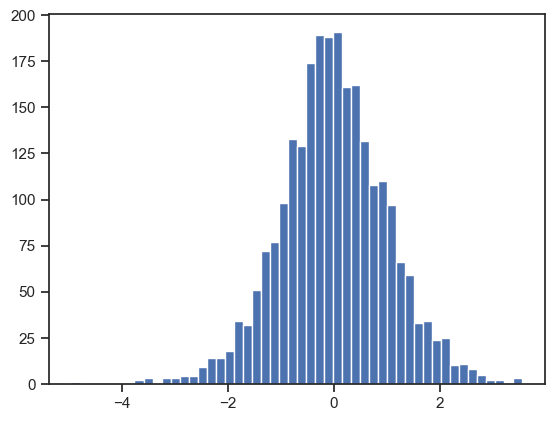

In [87]:
plt.hist(sc2_data, 50)
plt.show()